In [32]:
# import needed libraries
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc_file_defaults
import seaborn as sns 
import scanpy as sc
from statannot import add_stat_annotation
from statannotations.Annotator import Annotator

In [33]:
from sklearn import preprocessing
import logging
logger = logging.getLogger()

def normalise(adata,quantile= 0.95):
    if isinstance(adata, sc.AnnData):
        data =  adata.X
    else:
        data = adata.copy()
    if np.all(data<=1):
        logger.warning('data seem already normalised, skipping normalisation :)')
        return adata
    q = np.nanquantile(data,q = quantile,axis = 0)
    data = data/q
    data[data>1] = 1
    if isinstance(adata, sc.AnnData):
        adata.X = data
        return adata
    else:
        return data

def quality_control(intensities,low_gene_active = 0.2,high_gene_active = 0.5):
    if 'pass_qc' in intensities.columns:
        return intensities['pass_qc']
    intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    #For phenotyping , we  want the cells to express some markers, but not all together at the same time.
    #We are gonna consider the set of markers that we use for phenotyping

    markers_4_phenotyping = ['CD14', 'CD16', 'CD163', 'Pan-keratin',
                             'CD11b', 'CD107a', 'CD45', 'CD44',
                             'CD366', 'FOXP3', 'CD4', 'E-Cadherin', 
                             'CD68', 'HLA-DR-DQ-DP', 'CD20', 'CD8a',
                             'Beta-Catenin', 'B7-H4', 'Granzyme-B', 'CD3',
                             'CD45RO', 'Alpha-SMA', 'Vimentin', 'CD31']
    intensities_protein =    normalise(intensities_protein,0.95)# reconsider this TODO
    A = intensities_protein.loc[:,markers_4_phenotyping]
    cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
    cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11
    dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
    dna_thr = np.quantile(dna_count,0.05)
    dna_cond = dna_count>dna_thr
    cond = cond_few_genes_in_cell& cond_many_genes_in_cell&dna_cond
    return cond

def generate_anndata_from_cell_table(cell_table_path = None,biosamples_path = None,save = False,normalise_key = None):
    '''
    Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from Pixie. I filter out images with less than 1000 cells 
    Also I remove cells with the lowest 5%
    
    '''
    base_dir = "../"
    
    if cell_table_path is None:
        cell_table_path = os.path.join(base_dir, 'segmentation', 'cell_table', 'cell_table_size_normalized_cell_labels.csv')
    if biosamples_path is None:
        biosamples_path = base_dir+'IMC_data/ExtraDocs/processed_response.csv'
    
    cell_table = pd.read_csv(cell_table_path,index_col=False)
    if 'cell_meta_cluster' in cell_table.columns:
        cell_table = cell_table[cell_table['cell_meta_cluster']!='Unassigned']#remove cells that have not been assigned yet

    if 'qc_pass' not in cell_table.columns:
        logger.info('Generating quality control mask')
        qc_pass = quality_control(cell_table)
        cell_table['qc_pass'] = qc_pass
        logger.info('writing the cell table file at '+cell_table_path)
        cell_table.to_csv(cell_table_path,index = False)

    biosamples =pd.read_csv(biosamples_path)
    intensities_protein = cell_table.iloc[:,2:cell_table.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    #I don't think it is a good idea of using'Carboplatin_nuclear'. for small nuclei, the density shoot to high value
    #intensities_protein['Carboplatin'] = cell_table['Carboplatin_nuclear']
    logger.info('Finished loading, now create the anndata object')
    adata = sc.AnnData(intensities_protein, obsm={"spatial": cell_table[['centroid-0', 'centroid-1']].values})
    try:
        adata.obs['Pixie'] = pd.Categorical(cell_table.cell_meta_cluster.values.astype(str))
    except:
        print('cell type label not present')
    adata.obs['acquisition_ID'] = cell_table.fov.values
    adata.obs['Leap_ID'] = adata.obs.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
    adata.obs['Leap_ID'] = adata.obs.Leap_ID.str[:7]#leap_ID should be Leap123, anything more is stripped
    adata.obs = adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')#merging the metadata info, so that patient response is propagated to eaxch cell
    adata.obs['qc_pass'] = cell_table['qc_pass'].values
    if 'kmeans_neighborhood' in cell_table.columns:
        adata.obs['neighborhood'] = cell_table['kmeans_neighborhood'].values
    adata.raw = adata#raw data are unfiltered and unnormalised
    
    adata.X[np.isnan(adata.X)] =0#the nan comes when a  segmented file does not have the corresponding channel tiff file. That happened for the Carboplatin on a release that dates to Jan 24. On a new full process of data, check that this is not required anymore
    sc.pp.log1p(adata,copy = False)
    if normalise_key is None:
        #Normalise each channel independently by quantile
        adata = normalise(adata,quantile=0.95) # Consider removing
    else:
        if normalise_key in adata.obs.columns:
            normalise_by_group(adata,group_key = normalise_key,quantile=0.95)
        else:
            raise ValueError(normalise_key+' not in adata.obs.columns')
    adata.layers['scaled'] = preprocessing.StandardScaler().fit_transform(adata.X)
    #sc.tl.pca(adata,layer='scaled')

    if save:
        data_folder = '~/Boston/Analysis/data/'
        filename = 'sc_protein.h5ad'
        if not os.path.exists(data_folder):
            os.makedirs(data_folder)

            adata.write(data_folder+filename)

    return adata
generate_anndata_from_ark_analysis = generate_anndata_from_cell_table

In [34]:
adata2 = generate_anndata_from_ark_analysis(cell_table_path='/home/luciana/devices/Delta_Tissue/IMC/IMC_analysis/results_analysis/NeighbourhoodsKi67/cell_meta_cluster_radius20_frequency/updated_cell_table_Ki67_kmeans_nh_12.csv',biosamples_path='/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/CleanCohort_Metadata.csv')

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [35]:
adata2.obs['Pixie'].replace('B cell', 'Unassigned', inplace=True)
adata2.obs['Pixie'].replace('Macrophage', 'Macrophage M1', inplace=True)
adata2.obs['Pixie'].replace('Monocyte', 'NonCl Monocyte', inplace=True)

In [36]:
adata2 = adata2[adata2.obs['Pixie']!='Unassigned']

In [37]:
adata2.obs['neighborhood'] = adata2.obs['neighborhood'].fillna('Unassigned')
adata2.obs

/tmp/ipykernel_230156/76232938.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata2.obs['neighborhood'] = adata2.obs['neighborhood'].fillna('Unassigned')


,Pixie,acquisition_ID,Leap_ID,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch,qc_pass,neighborhood
index,,,,,,,,,,,,,,,,,,
0,CD8 T cell,Leap001_10,LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,False,9.0
1,Cancer cell,Leap001_10,LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,False,7.0
2,CD8 T cell,Leap001_10,LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,False,7.0
3,Memory CD8 T cell,Leap001_10,LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,True,3.0
4,B7H4 Cancer cell,Leap001_10,LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,False,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4241903,Cancer cell Prol,Leap150_9,LEAP150,Core,Cycle1,mid-early,EC-T-carbo,Responder,0.901,1,FROZEN,False,True,Responder,57,7,False,3.0
4241904,CD8 T cell,Leap150_9,LEAP150,Core,Cycle1,mid-early,EC-T-carbo,Responder,0.901,1,FROZEN,False,True,Responder,57,7,True,12.0
4241905,Int Monocyte,Leap150_9,LEAP150,Core,Cycle1,mid-early,EC-T-carbo,Responder,0.901,1,FROZEN,False,True,Responder,57,7,False,9.0


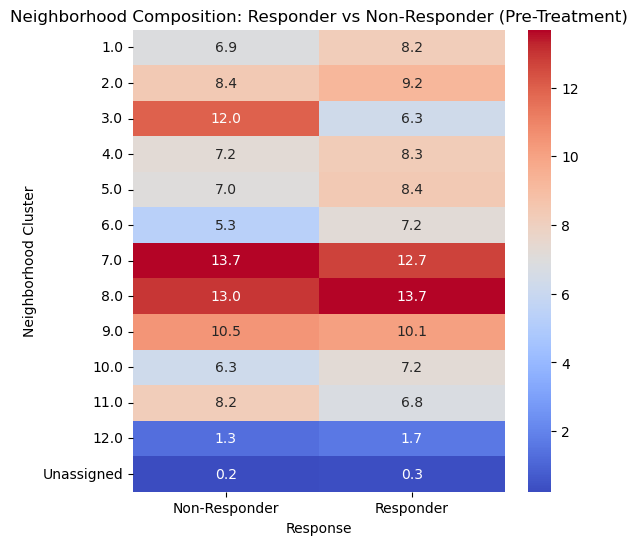

In [38]:
# Filter pre-treatment data for responder vs non-responder comparison
pre_treatment = adata2[adata2.obs['Sample_Type_(pre/post treatment)'] == 'pre']
pre_treatment =pd.DataFrame(pre_treatment.obs)

# Calculate neighborhood percentages for responder vs non-responder (pre-treatment)
neighborhood_counts = (
    pre_treatment.groupby(['Response', 'neighborhood'])
    .size()
    .reset_index(name='count')  # Avoids duplication issues
)

# Calculate percentages
neighborhood_summary = neighborhood_counts.copy()
neighborhood_summary['percentage'] = (
    neighborhood_summary.groupby('Response')['count']
    .transform(lambda x: x / x.sum() * 100)
)

# Visualization 1: Group-Level Heatmap
plt.figure(figsize=(6, 6))
heatmap_data = neighborhood_summary.pivot(index='neighborhood', columns='Response', values='percentage')
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".1f")
plt.title("Neighborhood Composition: Responder vs Non-Responder (Pre-Treatment)")
plt.ylabel("Neighborhood Cluster")
plt.xlabel("Response")

#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_percent_Pretreatment.png',format='png', dpi=600, bbox_inches='tight')

plt.show()


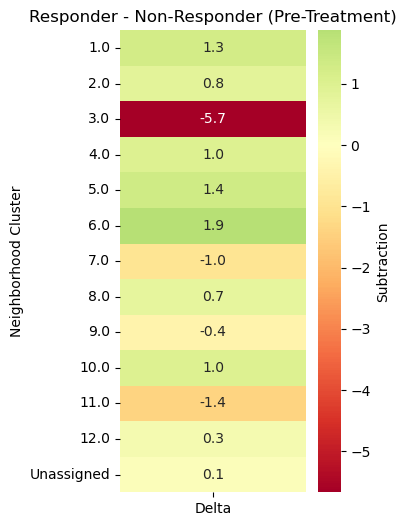

In [39]:
# 3. Visualization: Delta Heatmap (change in percentages)
delta_data = heatmap_data.copy()
delta_data['Delta'] = delta_data.iloc[:, 1] - delta_data.iloc[:, 0]  # Assumes responder is column 1, non-responder is column 0
plt.figure(figsize=(3, 6))
sns.heatmap(delta_data[['Delta']], cmap='RdYlGn', annot=True, fmt=".1f", cbar_kws={'label': 'Subtraction'}, center=0)
plt.title("Responder - Non-Responder (Pre-Treatment)")
plt.ylabel("Neighborhood Cluster")
plt.xlabel("")
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_subtraction_Pre.png',format='png', dpi=600, bbox_inches='tight')

plt.show()

## Cell type neighbourhood composition

/tmp/ipykernel_230156/768279020.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pre_treatment.groupby(['Response', 'neighborhood', 'Pixie'])


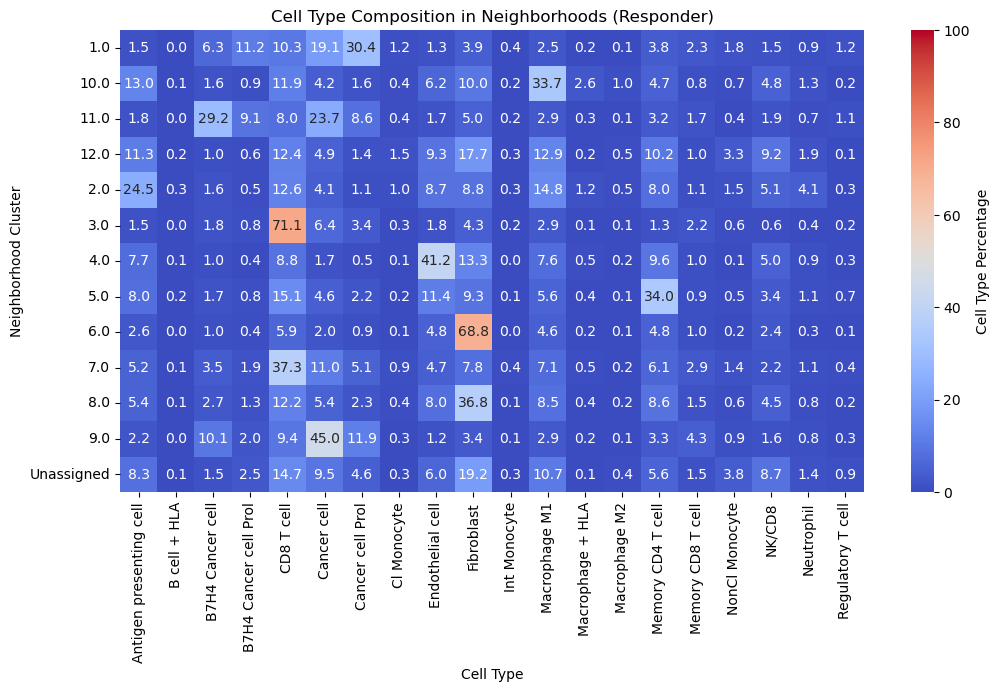

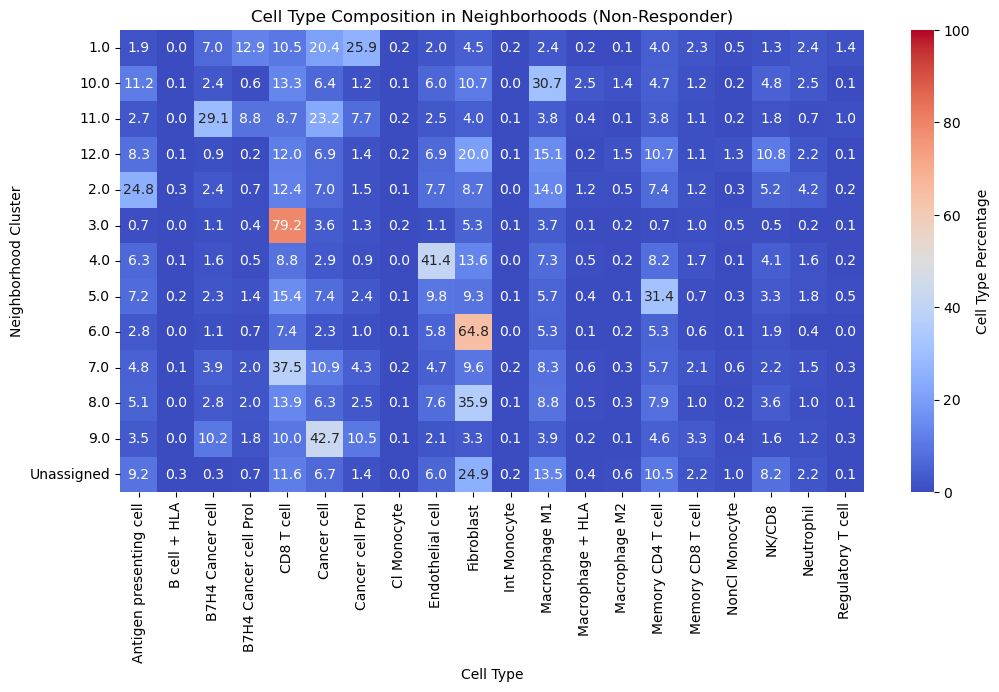

In [40]:
pre_treatment = adata2[adata2.obs['Sample_Type_(pre/post treatment)'] == 'pre']
pre_treatment =pd.DataFrame(pre_treatment.obs)

pre_treatment['neighborhood'] = pre_treatment['neighborhood'].astype(str)  # Convert to string

# Calculate the cell type percentages per neighborhood, grouped by response (responder vs non-responder)
# This calculates the percentage of each cell type within each neighborhood for each group
cell_type_percentage = (
    pre_treatment.groupby(['Response', 'neighborhood', 'Pixie'])
    .size()
    .reset_index(name='count')
)

# Calculate total count of cells in each neighborhood for each response group (responder vs non-responder)
total_cells_per_neighborhood = (
    pre_treatment.groupby(['Response', 'neighborhood'])
    .size()
    .reset_index(name='total_cells')
)

# Merge the total counts with the cell type counts
cell_type_percentage = pd.merge(cell_type_percentage, total_cells_per_neighborhood, on=['Response', 'neighborhood'])

# Calculate percentage of each cell type within each neighborhood
cell_type_percentage['percentage'] = (cell_type_percentage['count'] / cell_type_percentage['total_cells']) * 100

responder = cell_type_percentage[cell_type_percentage['Response'] == 'Responder']
nonresponder = cell_type_percentage[cell_type_percentage['Response'] == 'Non-Responder']


# Pivot the table to create a matrix for the heatmap
heatmap_data1 = responder.pivot_table(
    index='neighborhood', 
    columns='Pixie', 
    values='percentage', 
    aggfunc='mean'  # Use 'mean' to average the percentages for each neighborhood
)

heatmap_data2 = nonresponder.pivot_table(
    index='neighborhood', 
    columns='Pixie', 
    values='percentage', 
    aggfunc='mean'  # Use 'mean' to average the percentages for each neighborhood
)



# Visualize the heatmap for each group (Responder vs Non-Responder)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data1, cmap='coolwarm', annot=True, fmt=".1f", cbar_kws={'label': 'Cell Type Percentage'},vmax=100,vmin=0)
plt.title("Cell Type Composition in Neighborhoods (Responder)")
plt.xlabel("Cell Type")
plt.ylabel("Neighborhood Cluster")
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/CellTypeNeighComp_Pre_Resp.png',format='png', dpi=600, bbox_inches='tight')


plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data2, cmap='coolwarm', annot=True, fmt=".1f", cbar_kws={'label': 'Cell Type Percentage'},vmax=100,vmin=0)
plt.title("Cell Type Composition in Neighborhoods (Non-Responder)")
plt.xlabel("Cell Type")
plt.ylabel("Neighborhood Cluster")
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/CellTypeNeighComp_Pre_NonResp.png',format='png', dpi=600, bbox_inches='tight')

plt.show()


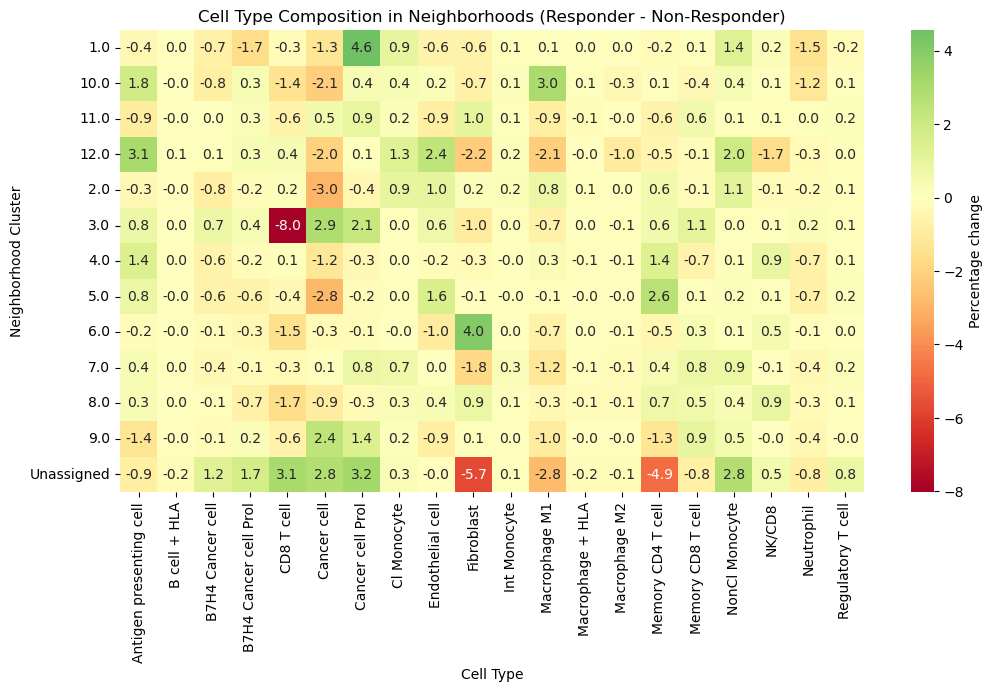

In [41]:
substraction = heatmap_data1 - heatmap_data2

substraction

plt.figure(figsize=(12, 6))
sns.heatmap(substraction, cmap='RdYlGn', annot=True, fmt=".1f", cbar_kws={'label': 'Percentage change'},center=0)#,vmax=100,vmin=0)
plt.title("Cell Type Composition in Neighborhoods (Responder - Non-Responder)")
plt.xlabel("Cell Type")
plt.ylabel("Neighborhood Cluster")
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/CellTypeNeighComp_Pre_Subtraction.png',format='png', dpi=600, bbox_inches='tight')


plt.show()